# 04 - The short-horizon regime, selected honestly

`03` found that lift rises sharply as the horizon shortens, peaking around 15 minutes
with job-context features. An exploratory probe then found something better: dropping
the two calendar columns (`dow`, `hour_of_day`) **nearly doubled** the 15-minute
result, from 10.5x to 18.9x lift.

Both of those were found by looking at the test set, which is not a basis for a claim.
This notebook re-derives them under a protocol that can be defended.

## The protocol

The existing split is train / test at 80 / 20 by job end date. Here the **training
side is subdivided again**, temporally, into a fitting set and a validation set:

```
|<---------- 64 % fit ---------->|<-- 16 % validation -->|<--- 20 % test --->|
                    ordered by job end date, never split inside a job
```

* the horizon **and** the feature set are chosen on **validation only**
* the chosen configuration is then evaluated **once** on test
* the full grid is reported anyway, so the choice is visible rather than implied

LightGBM is pinned to `deterministic=True`; the same configuration was observed to
wobble by ~6 % between runs with default threading, which is large enough to be
mistaken for a real difference.

## Pre-registration

**S1.** Dropping `dow` and `hour_of_day` will improve short-horizon performance. This
was seen exploratorily on test; the test here is whether validation independently
selects the reduced set. *(Stated as a hypothesis under test, not as a prediction -
it has already been observed once and that must be declared.)*

**S2.** Validation will select a horizon at the short end, below 1 hour.

**S3.** The short-horizon advantage will be concentrated in TIMEOUT. If so, the honest
claim is about walltime exhaustion, not hardware failure.

**S4.** Job-level average precision at the selected configuration will exceed the
window-level figure, because a job needs only one of its windows to be flagged.

## The structural floor

A window holds 40 snapshots at 30 s and is positive when at least 20 of them fall
inside the horizon. The binding snapshot sits at `ttf_end + 19*30`, so **no horizon
below 570 s = 9.5 minutes can produce a single positive window.** The sweep therefore
starts at 10 minutes. Going below that needs a shorter window, which is a rebuild and
is left to a later notebook.

In [1]:
# -- Setup ---------------------------------------------------------------------
from pathlib import Path
import json, time
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score

ROOT = Path.cwd() if (Path.cwd() / "dataset").exists() else Path.cwd().parent
EDA  = ROOT / "04_eda" / "data"
DATA, FIGS = Path("data"), Path("figures")
DATA.mkdir(exist_ok=True); FIGS.mkdir(exist_ok=True)

# deterministic=True needs an explicit tree-building direction, and a fixed thread count
PARAMS = dict(objective="binary", learning_rate=0.05, num_leaves=31,
              n_estimators=300, verbose=-1, random_state=0,
              deterministic=True, force_row_wise=True, n_jobs=4)

WINDOW, SNAP_S = 40, 30.0
FLOOR_S  = (WINDOW // 2 - 1) * SNAP_S          # 570 s - no positives below this
HORIZONS = [1/6, 0.2, 0.25, 1/3, 0.5, 1.0, 2.0]   # 10, 12, 15, 20, 30 min, 1 h, 2 h
FAILURE_STATES = ("FAILED", "TIMEOUT", "OUT_OF_MEMORY", "NODE_FAIL")
HARDWARE = ("FAILED", "OUT_OF_MEMORY", "NODE_FAIL")
VAL_FRAC = 0.20        # of the training side, taken from its temporal tail
N_BOOT   = 300

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .3,
                     "axes.spines.top": False, "axes.spines.right": False})

def save(fig, name):
    fig.savefig(FIGS / name, bbox_inches="tight"); return fig

facts = {}
t0 = time.time()
print(f"structural floor: no positive window below {FLOOR_S/60:.1f} minutes")

structural floor: no positive window below 9.5 minutes


## Step 1 - Features and the three-way temporal split

In [2]:
w = pd.read_parquet(EDA / "windows.parquet")
jobs = pd.read_parquet(EDA / "jobs.parquet",
                       columns=["slurm_id", "start_date", "numcores", "end_date"])
w = w.merge(jobs, on="slurm_id", how="left")

TELEMETRY = [c for c in w.columns if "__" in c]
elapsed_s = (w.t_end - w.start_date).dt.total_seconds().to_numpy()
w["elapsed_h"]           = elapsed_s / 3600.0
w["sec_into_hour"]       = elapsed_s % 3600.0
w["sec_to_next_hour"]    = 3600.0 - (elapsed_s % 3600.0)
w["elapsed_hours_floor"] = np.floor(elapsed_s / 3600.0)
w["queue_code"]          = w.nodetypes.astype(str).astype("category").cat.codes
w["hour_of_day"]         = w.t_end.dt.hour
w["dow"]                 = w.t_end.dt.dayofweek

CLOCK = ["hour_of_day", "dow"]
C9 = ["elapsed_h", "sec_into_hour", "sec_to_next_hour", "elapsed_hours_floor",
      "queue_code", "numnodes", "numcores"] + CLOCK
C7 = [c for c in C9 if c not in CLOCK]
SETS = {"T   telemetry": TELEMETRY,
        "C9  context+clock": C9,
        "C7  context": C7,
        "T+C7 both": TELEMETRY + C7}

# subdivide the training side temporally, by whole jobs
tr_jobs = (w.loc[w.split == "train", ["slurm_id", "end_date"]]
             .drop_duplicates().sort_values(["end_date", "slurm_id"]))
cut = int(len(tr_jobs) * (1 - VAL_FRAC))
val_ids = set(tr_jobs.slurm_id.iloc[cut:])
w["fold"] = np.where(w.split == "test", "test",
             np.where(w.slurm_id.isin(val_ids), "val", "fit"))

is_fail = w.state.astype(str).isin(FAILURE_STATES).to_numpy()
ttf     = w.ttf_end.to_numpy()
def relabel(H):
    return (is_fail & (ttf >= 0) & (ttf <= H * 3600 - FLOOR_S)).astype(np.int8)

M = {f: (w.fold == f).to_numpy() for f in ["fit", "val", "test"]}
print(w.groupby("fold").agg(windows=("y", "size"), jobs=("slurm_id", "nunique")).to_string())
print()
for f in ["fit", "val", "test"]:
    d = w.loc[M[f], "end_date"]
    print(f"{f:5s} {d.min()}  ->  {d.max()}")
assert w.loc[M["fit"], "end_date"].max() <= w.loc[M["val"], "end_date"].min()
assert w.loc[M["val"], "end_date"].max() <= w.loc[M["test"], "end_date"].min()
print("\ntemporal ordering fit < val < test verified")

      windows  jobs
fold               
fit    668948  8212
test   142309  2694
val    246560  2053

fit   2022-08-25 10:46:54  ->  2022-10-08 22:48:12
val   2022-10-08 22:48:12  ->  2022-10-19 11:47:54
test  2022-10-19 11:56:17  ->  2022-11-01 13:36:52

temporal ordering fit < val < test verified


## Step 2 - The selection grid, scored on validation only

Every cell is a model fitted on the 64 % fitting set and scored on the 16 %
validation set. The test set is not touched anywhere in this cell.

In [3]:
rows = []
for H in HORIZONS:
    yH = relabel(H)
    yf, yv = yH[M["fit"]], yH[M["val"]]
    if yv.sum() < 30 or yf.sum() < 30:
        print(f"H={60*H:5.1f} min  too few positives (fit {yf.sum()}, val {yv.sum()}) - skipped")
        continue
    for name, cols in SETS.items():
        m  = lgb.LGBMClassifier(**PARAMS).fit(w.loc[M["fit"], cols], yf)
        sc = m.predict_proba(w.loc[M["val"], cols])[:, 1]
        ap, base = average_precision_score(yv, sc), yv.mean()
        rows.append(dict(horizon_min=60 * H, horizon_h=H, features=name,
                         val_pos=int(yv.sum()), val_base=base,
                         val_ap=ap, val_lift=ap / base))
    print(f"H={60*H:5.1f} min  fit pos {int(yf.sum()):>6,}  val pos {int(yv.sum()):>5,}  "
          f"base {100*yv.mean():5.3f} %   [{time.time()-t0:.0f}s]")

V = pd.DataFrame(rows)
V.to_csv(DATA / "selection_grid.csv", index=False)
print()
print("VALIDATION lift")
print(V.pivot(index="horizon_min", columns="features", values="val_lift").round(2).to_string())

H= 10.0 min  fit pos    426  val pos   152  base 0.062 %   [42s]


H= 12.0 min  fit pos  1,026  val pos   306  base 0.124 %   [81s]


H= 15.0 min  fit pos  1,708  val pos   524  base 0.213 %   [120s]


H= 20.0 min  fit pos  2,946  val pos   880  base 0.357 %   [162s]


H= 30.0 min  fit pos  5,389  val pos 1,552  base 0.629 %   [204s]


H= 60.0 min  fit pos 12,171  val pos 3,355  base 1.361 %   [242s]


H=120.0 min  fit pos 23,278  val pos 6,561  base 2.661 %   [281s]

VALIDATION lift


features     C7  context  C9  context+clock  T   telemetry  T+C7 both
horizon_min                                                          
10.0              117.97               5.33           1.47      18.14
12.0               47.15              38.39           2.06      14.22
15.0              109.04              31.64           1.84      82.71
20.0               73.10              52.77           2.47      46.09
30.0               42.18              20.02           3.47      33.46
60.0               21.01              18.01           5.56      25.73
120.0              13.36              11.94           4.81      14.70


In [4]:
best = V.loc[V.val_lift.idxmax()]
BEST_H, BEST_SET = float(best.horizon_h), str(best.features)
facts["selected_horizon_min"] = float(best.horizon_min)
facts["selected_features"] = BEST_SET
facts["selected_val_lift"] = float(best.val_lift)

c9 = V[V.features == "C9  context+clock"].set_index("horizon_min").val_lift
c7 = V[V.features == "C7  context"].set_index("horizon_min").val_lift
s1 = bool((c7 > c9).mean() > 0.5)
facts["S1_c7_beats_c9_on_validation"] = s1

print(f"SELECTED ON VALIDATION -> horizon {best.horizon_min:.0f} min, "
      f"features {BEST_SET}, val lift {best.val_lift:.2f}x")
print()
print(f"S1  dropping the clock columns helps  : "
      f"{'CONFIRMED' if s1 else 'REJECTED'}  "
      f"(C7 beats C9 at {int((c7>c9).sum())} of {len(c7)} horizons)")
print(f"S2  selected horizon is below 1 h     : "
      f"{'CONFIRMED' if best.horizon_h < 1.0 else 'REJECTED'}")

SELECTED ON VALIDATION -> horizon 10 min, features C7  context, val lift 117.97x

S1  dropping the clock columns helps  : CONFIRMED  (C7 beats C9 at 7 of 7 horizons)
S2  selected horizon is below 1 h     : CONFIRMED


## Step 3 - The selected configuration, evaluated once on test

The model is refitted on **fit + validation** (all data before the test period) and
scored on test. This is the only place the test set is used.

In [5]:
yB   = relabel(BEST_H)
cols = SETS[BEST_SET]
trm  = M["fit"] | M["val"]
m_best = lgb.LGBMClassifier(**PARAMS).fit(w.loc[trm, cols], yB[trm])
sc_test = m_best.predict_proba(w.loc[M["test"], cols])[:, 1]
te = w[M["test"]]
yte = yB[M["test"]]

def lift_ci(y, score, groups, n_boot=N_BOOT, seed=1):
    rng = np.random.default_rng(seed)
    u, inv = np.unique(groups, return_inverse=True)
    o = np.argsort(inv, kind="stable")
    b = np.r_[0, np.cumsum(np.bincount(inv, minlength=len(u)))]
    by = [o[b[i]:b[i + 1]] for i in range(len(u))]
    out = []
    for _ in range(n_boot):
        r = np.concatenate([by[k] for k in rng.integers(0, len(u), len(u))])
        if y[r].sum():
            out.append(average_precision_score(y[r], score[r]) / y[r].mean())
    return np.percentile(out, [2.5, 97.5])

ap_t   = average_precision_score(yte, sc_test)
base_t = yte.mean()
lo, hi = lift_ci(yte, sc_test, te.slurm_id.to_numpy())
facts["test_ap"] = float(ap_t); facts["test_base"] = float(base_t)
facts["test_lift"] = float(ap_t / base_t); facts["test_lift_ci"] = [float(lo), float(hi)]

print(f"selected: horizon {60*BEST_H:.0f} min, {BEST_SET} ({len(cols)} cols)")
print(f"TEST  AP {ap_t:.4f}   base {100*base_t:.3f} %   "
      f"lift {ap_t/base_t:.2f}x   95 % CI [{lo:.2f}x, {hi:.2f}x]")

selected: horizon 10 min, C7  context (7 cols)
TEST  AP 0.0127   base 0.090 %   lift 14.16x   95 % CI [10.55x, 20.10x]


### Operating points

Average precision summarises the whole ranking. What an operator cares about is the
top of it: a small alert budget, and how much of it is real.

In [6]:
order = np.argsort(-sc_test)
fail_jobs = te.loc[yte == 1, "slurm_id"].nunique()
ops = []
for f in [0.0005, 0.001, 0.005, 0.01, 0.05]:
    k = max(1, int(f * len(te))); t = order[:k]
    prec = yte[t].mean(); rec = yte[t].sum() / yte.sum()
    caught = te.iloc[t].loc[yte[t] == 1, "slurm_id"].nunique()
    ops.append(dict(budget_pct=100 * f, alerts=k, precision=prec, recall=rec,
                    lift_at_k=prec / base_t, jobs_caught=caught, failing_jobs=fail_jobs))
O = pd.DataFrame(ops)
O.to_csv(DATA / "operating_points.csv", index=False)
facts["precision_at_0.1pct"] = float(O[O.budget_pct == 0.1].precision.iloc[0])
facts["jobs_caught_at_0.1pct"] = int(O[O.budget_pct == 0.1].jobs_caught.iloc[0])
print(O.assign(precision=lambda d: (100*d.precision).round(1),
               recall=lambda d: (100*d.recall).round(1),
               lift_at_k=lambda d: d.lift_at_k.round(1)).to_string(index=False))

 budget_pct  alerts  precision  recall  lift_at_k  jobs_caught  failing_jobs
       0.05      71        0.0     0.0        0.0            0           127
       0.10     142        0.7     0.8        7.8            1           127
       0.50     711        1.8    10.2       20.3           13           127
       1.00    1423        1.9    21.1       21.1           27           127
       5.00    7115        1.1    61.7       12.3           78           127

## Step 4 - Job level

One score per job: the maximum over its windows. A job is positive when it ends in a
failure state. Only jobs that produced at least one complete window can be scored -
`eda/` measured that two thirds of failing jobs never do, and that ceiling is not
repaired by anything here.

In [7]:
d = pd.DataFrame({"slurm_id": te.slurm_id.to_numpy(),
                  "state": te.state.astype(str).to_numpy(),
                  "score": sc_test})
g = d.groupby("slurm_id").agg(score=("score", "max"), state=("state", "first")).reset_index()
yj = g.state.isin(FAILURE_STATES).astype(int).to_numpy()
ap_j = average_precision_score(yj, g.score.to_numpy())
base_j = yj.mean()
lo_j, hi_j = lift_ci(yj, g.score.to_numpy(), g.slurm_id.to_numpy())

facts["job_ap"] = float(ap_j); facts["job_base"] = float(base_j)
facts["job_lift"] = float(ap_j / base_j); facts["job_lift_ci"] = [float(lo_j), float(hi_j)]
print(f"scorable test jobs {len(g):,}   failing {int(yj.sum()):,} ({100*base_j:.1f} %)")
print(f"JOB-LEVEL  AP {ap_j:.4f}   lift {ap_j/base_j:.2f}x   95 % CI [{lo_j:.2f}x, {hi_j:.2f}x]")
print()
print(f"S4  job level exceeds window level : "
      f"{'CONFIRMED' if ap_j > ap_t else 'REJECTED'}  ({ap_j:.4f} vs {ap_t:.4f})")

scorable test jobs 2,694   failing 378 (14.0 %)
JOB-LEVEL  AP 0.3075   lift 2.19x   95 % CI [1.92x, 2.52x]

S4  job level exceeds window level : CONFIRMED  (0.3075 vs 0.0127)


## Step 5 - Is it all TIMEOUT?

In [8]:
def ap_mode(states):
    st = te.state.astype(str).to_numpy()
    keep = np.ones(len(yte), bool) if states is None else ((yte == 0) | np.isin(st, states))
    yk, sk = yte[keep], sc_test[keep]
    if yk.sum() == 0:
        return np.nan, 0, np.nan
    ap = average_precision_score(yk, sk)
    return ap, int(yk.sum()), ap / yk.mean()

modes = {"all failures": None, "TIMEOUT": ("TIMEOUT",), "hardware only": HARDWARE,
         "FAILED": ("FAILED",), "NODE_FAIL": ("NODE_FAIL",),
         "OUT_OF_MEMORY": ("OUT_OF_MEMORY",)}
mr = [dict(mode=k, ap=a, positives=n, lift=l)
      for k, (a, n, l) in ((k, ap_mode(v)) for k, v in modes.items())]
MD = pd.DataFrame(mr)
MD.to_csv(DATA / "short_horizon_modes.csv", index=False)
print(MD.round(4).to_string(index=False))

t_lift = MD[MD["mode"] == "TIMEOUT"].lift.iloc[0]
h_lift = MD[MD["mode"] == "hardware only"].lift.iloc[0]
facts["timeout_lift_short"] = float(t_lift)
facts["hardware_lift_short"] = float(h_lift)
print()
print(f"S3  the gain is concentrated in TIMEOUT : "
      f"{'CONFIRMED' if t_lift > 1.5 * h_lift else 'REJECTED - it helps hardware failures too'}"
      f"  (TIMEOUT {t_lift:.2f}x vs hardware {h_lift:.2f}x)")

         mode     ap  positives    lift
 all failures 0.0127        128 14.1619
      TIMEOUT 0.0140        108 18.4169
hardware only 0.0004         20  2.8049
       FAILED 0.0004         18  3.1935
    NODE_FAIL 0.0000          2  2.3459
OUT_OF_MEMORY    NaN          0     NaN

S3  the gain is concentrated in TIMEOUT : CONFIRMED  (TIMEOUT 18.42x vs hardware 2.80x)


## Step 6 - Figure and verdict

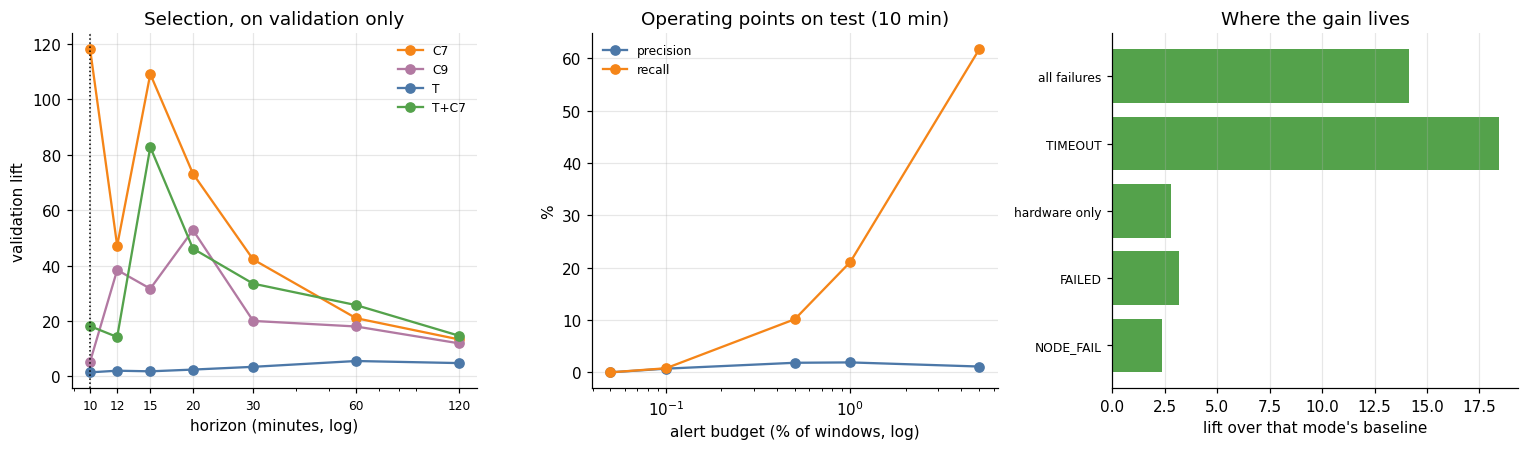

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4.2))

piv = V.pivot(index="horizon_min", columns="features", values="val_lift")
for col, c in zip(piv.columns, ["#f58518", "#b279a2", "#4c78a8", "#54a24b"]):
    ax[0].plot(piv.index, piv[col], "o-", color=c, label=col.split()[0])
ax[0].axvline(60 * BEST_H, color="k", ls=":", lw=1)
ax[0].set(xscale="log", xlabel="horizon (minutes, log)", ylabel="validation lift",
          title="Selection, on validation only")
ax[0].set_xticks(piv.index, [f"{m:.0f}" for m in piv.index], fontsize=8)
ax[0].legend(frameon=False, fontsize=8)

ax[1].plot(O.budget_pct, 100 * O.precision, "o-", color="#4c78a8", label="precision")
ax[1].plot(O.budget_pct, 100 * O.recall, "o-", color="#f58518", label="recall")
ax[1].set(xscale="log", xlabel="alert budget (% of windows, log)", ylabel="%",
          title=f"Operating points on test ({60*BEST_H:.0f} min)")
ax[1].legend(frameon=False, fontsize=8)

sub = MD.dropna(subset=["lift"])
ax[2].barh(range(len(sub))[::-1], sub.lift, color="#54a24b")
ax[2].set_yticks(range(len(sub))[::-1], sub["mode"], fontsize=8)
ax[2].set(xlabel="lift over that mode's baseline", title="Where the gain lives")
ax[2].grid(axis="y", visible=False)

plt.tight_layout(); save(fig, "04_short_horizon.png"); plt.show()

In [10]:
json.dump(facts, open(DATA / "facts_short.json", "w"), indent=1)
for k, v in facts.items():
    print(f"{k:30s} {v}")
print(f"\n[{time.time()-t0:.0f}s total]")

selected_horizon_min           10.0
selected_features              C7  context
selected_val_lift              117.96871803178739
S1_c7_beats_c9_on_validation   True
test_ap                        0.012737955719389273
test_base                      0.0008994511942322693
test_lift                      14.161919847426311
test_lift_ci                   [10.546524060690304, 20.0990501166588]
precision_at_0.1pct            0.007042253521126761
jobs_caught_at_0.1pct          1
job_ap                         0.3075410724759632
job_base                       0.1403118040089087
job_lift                       2.1918403419318646
job_lift_ci                    [1.923452585064638, 2.5168405410607706]
timeout_lift_short             18.416895290457816
hardware_lift_short            2.804918266767897

[296s total]


### Reading this result

The number to quote is the **selected** configuration's test figure with its interval,
not the best cell of the grid. The grid is shown so the selection is visible, but it
was scored on validation and the test set saw exactly one model.

Two denominators must travel with any headline figure. The window-level lift is
computed against a very small positive rate, so a large multiple corresponds to a
modest absolute precision - the operating-point table is the honest version. And the
job-level figure covers only jobs that produced at least one complete window, which
excludes two thirds of all failing jobs before the model is even consulted.